# Task 2: Credit Risk Prediction

## Objective
Predict whether a loan applicant is likely to default or not.

## Tools Used
- pandas
- matplotlib
- seaborn
- scikit-learn

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

sns.set(style="whitegrid")

In [37]:
loan = pd.read_csv("dataset\loan_data.csv")

loan.head()

<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\Akhter Laptops\AppData\Local\Temp\ipykernel_15772\1871109911.py:1: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  loan = pd.read_csv("dataset\loan_data.csv")


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,12.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [38]:
print("Shape:", loan.shape)

print("Columns:", loan.columns)

loan.info()

loan.describe()

Shape: (614, 13)
Columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         593 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_A

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,593.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.185497,342.00000,0.842199
std,6109.041673,2926.248369,85.692958,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [39]:
loan.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [40]:
# fill missing values using forward fill
loan = loan.ffill()

# check missing values again
loan.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [41]:
le = LabelEncoder()

loan["Gender"] = le.fit_transform(loan["Gender"])
loan["Married"] = le.fit_transform(loan["Married"])
loan["Education"] = le.fit_transform(loan["Education"])
loan["Self_Employed"] = le.fit_transform(loan["Self_Employed"])
loan["Property_Area"] = le.fit_transform(loan["Property_Area"])
loan["Loan_Status"] = le.fit_transform(loan["Loan_Status"])

loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,12.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


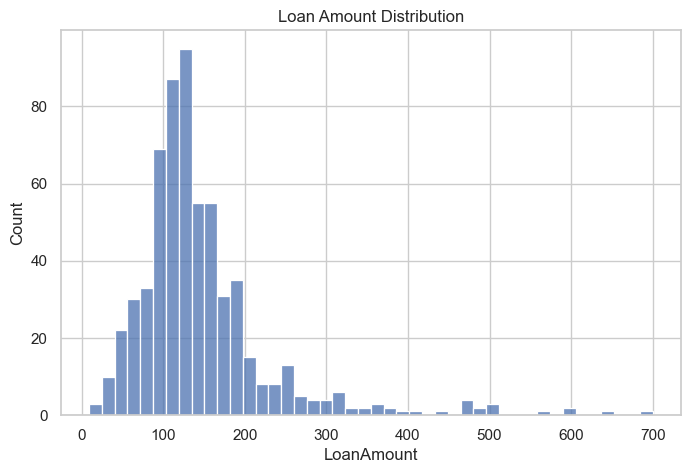

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(loan["LoanAmount"])

plt.title("Loan Amount Distribution")

plt.show()

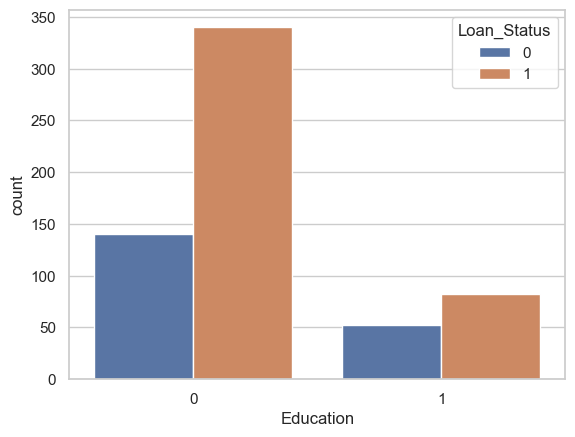

In [43]:
sns.countplot(x="Education", hue="Loan_Status", data=loan)

plt.show()

In [44]:
X = loan.drop("Loan_Status", axis=1)

y = loan["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
# Categorical columns → fill with mode (most frequent value)
categorical_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History", "Loan_Amount_Term"]
for col in categorical_cols:
    loan[col].fillna(loan[col].mode()[0], inplace=True)

# Numerical columns → fill with median
numerical_cols = ["LoanAmount"]
for col in numerical_cols:
    loan[col].fillna(loan[col].median(), inplace=True)

C:\Users\Akhter Laptops\AppData\Local\Temp\ipykernel_15772\4141971899.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  loan[col].fillna(loan[col].mode()[0], inplace=True)
C:\Users\Akhter Laptops\AppData\Local\Temp\ipykernel_15772\4141971899.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series throu

In [46]:
loan["LoanAmount"].fillna(loan["LoanAmount"].median(), inplace=True)

C:\Users\Akhter Laptops\AppData\Local\Temp\ipykernel_15772\2734796696.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  loan["LoanAmount"].fillna(loan["LoanAmount"].median(), inplace=True)


0       12.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [47]:
loan["LoanAmount"].fillna(loan["LoanAmount"].median(), inplace=True)

C:\Users\Akhter Laptops\AppData\Local\Temp\ipykernel_15772\2734796696.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  loan["LoanAmount"].fillna(loan["LoanAmount"].median(), inplace=True)


0       12.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [48]:
loan[loan["LoanAmount"].isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


In [49]:
loan["LoanAmount"] = pd.to_numeric(loan["LoanAmount"], errors="coerce")

In [50]:
loan["LoanAmount"].fillna(loan["LoanAmount"].median(), inplace=True)

C:\Users\Akhter Laptops\AppData\Local\Temp\ipykernel_15772\2734796696.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  loan["LoanAmount"].fillna(loan["LoanAmount"].median(), inplace=True)


0       12.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [51]:
loan.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [52]:
# Replace '3+' with 3 and convert entire column to integer
loan["Dependents"] = loan["Dependents"].replace("3+", 3).astype(int)

In [53]:
["Gender","Married","Education","Self_Employed","Property_Area","Loan_Status"]

['Gender',
 'Married',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [54]:
X = loan.drop(["Loan_ID","Loan_Status"], axis=1)

y = loan["Loan_Status"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

c:\Users\Akhter Laptops\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Calculate accuracy
acc = accuracy_score(y_test, predictions)
print("Accuracy:", acc)

# Confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8130081300813008
Confusion Matrix:
 [[21 22]
 [ 1 79]]


## Conclusion

- Logistic Regression predicts loan approval with good accuracy.
- Important factors: Credit History, Education, ApplicantIncome, LoanAmount.
- Confusion matrix shows correct and incorrect predictions.
- This model can help banks decide whether to approve loans.